<a href="https://colab.research.google.com/github/Mohammed42-AI42/-Mohammed42-AI42/blob/main/mbert_sentiment_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 mBERT Sentiment Analysis v3
### Multi-Dataset: AJGT + SemEval + ASTD + ArSAS + Amazon AR
### 3 Classes: Positive / Negative / Neutral


In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn gradio --quiet
print('✅ كل المكتبات تثبتت')

✅ كل المكتبات تثبتت


In [2]:
import os
import re
import gc
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [3]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset, load_dataset

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import gradio as gr
print('✅ كل الاستيرادات جاهزة')

✅ كل الاستيرادات جاهزة


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'الجهاز: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'ذاكرة: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️ اذهب لـ Runtime > Change runtime type > T4 GPU')

الجهاز: cuda
GPU: Tesla T4
ذاكرة: 15.6 GB


In [6]:
# تحميل وتجميع كل الداتا المتاحة
all_dfs = []

# ── 1. AJGT Arabic Tweets ──────────────────────────────
print('1️⃣ جاري تحميل AJGT...')
try:
    ajgt = load_dataset('ajgt_twitter_ar', trust_remote_code=True)
    label_map_ajgt = {0: 'negative', 1: 'positive'}
    rows = []
    for split in ajgt:
        for item in ajgt[split]:
            rows.append({
                'text':      item['text'],
                'label_raw': label_map_ajgt.get(item['label'], str(item['label'])),
                'source':    'AJGT'
            })
    df_ajgt = pd.DataFrame(rows)
    all_dfs.append(df_ajgt)
    print(f'   ✅ AJGT: {len(df_ajgt):,} جملة')
    print(f'   {df_ajgt["label_raw"].value_counts().to_dict()}')
except Exception as e:
    print(f'   ❌ AJGT فشل: {e}')

# ── 2. SemEval 2017 Arabic Sentiment ──────────────────
print('\n2️⃣ جاري تحميل SemEval Arabic...')
try:
    semeval = load_dataset('SemEvalArabic/semeval_2017_task4', trust_remote_code=True)
    label_map_sem = {
        0: 'negative', 1: 'neutral', 2: 'positive',
        'negative': 'negative', 'neutral': 'neutral', 'positive': 'positive',
        'NEG': 'negative', 'NEU': 'neutral', 'POS': 'positive'
    }
    rows = []
    for split in semeval:
        for item in semeval[split]:
            lbl = label_map_sem.get(item.get('label', item.get('sentiment', '')), None)
            txt = item.get('text', item.get('tweet', ''))
            if lbl and txt:
                rows.append({'text': txt, 'label_raw': lbl, 'source': 'SemEval'})
    df_semeval = pd.DataFrame(rows)
    all_dfs.append(df_semeval)
    print(f'   ✅ SemEval: {len(df_semeval):,} جملة')
    print(f'   {df_semeval["label_raw"].value_counts().to_dict()}')
except Exception as e:
    print(f'   ❌ SemEval فشل: {e}')

# ── 3. ASTD Dataset ────────────────────────────────────
print('\n3️⃣ جاري تحميل ASTD...')
try:
    astd = load_dataset('arbml/ASTD', trust_remote_code=True)
    label_map_astd = {
        0: 'negative', 1: 'positive', 2: 'neutral', 3: 'neutral',
        'Negative': 'negative', 'Positive': 'positive',
        'Neutral': 'neutral', 'Mixed': 'neutral'
    }
    rows = []
    for split in astd:
        for item in astd[split]:
            lbl = label_map_astd.get(item.get('label', ''), None)
            txt = item.get('text', '')
            if lbl and txt:
                rows.append({'text': txt, 'label_raw': lbl, 'source': 'ASTD'})
    df_astd = pd.DataFrame(rows)
    all_dfs.append(df_astd)
    print(f'   ✅ ASTD: {len(df_astd):,} جملة')
    print(f'   {df_astd["label_raw"].value_counts().to_dict()}')
except Exception as e:
    print(f'   ❌ ASTD فشل: {e}')

# ── 4. ArSAS Dataset ──────────────────────────────────
print('\n4️⃣ جاري تحميل ArSAS...')
try:
    arsas = load_dataset('arbml/ArSAS', trust_remote_code=True)
    label_map_arsas = {
        'Positive': 'positive', 'Negative': 'negative',
        'Neutral':  'neutral',  'Mixed':    'neutral',
        0: 'negative', 1: 'positive', 2: 'neutral'
    }
    rows = []
    for split in arsas:
        for item in arsas[split]:
            lbl = label_map_arsas.get(item.get('sentiment', item.get('label', '')), None)
            txt = item.get('text', item.get('tweet', ''))
            if lbl and txt:
                rows.append({'text': txt, 'label_raw': lbl, 'source': 'ArSAS'})
    df_arsas = pd.DataFrame(rows)
    all_dfs.append(df_arsas)
    print(f'   ✅ ArSAS: {len(df_arsas):,} جملة')
    print(f'   {df_arsas["label_raw"].value_counts().to_dict()}')
except Exception as e:
    print(f'   ❌ ArSAS فشل: {e}')

# ── 5. Amazon Reviews Arabic ──────────────────────────
print('\n5️⃣ جاري تحميل Amazon Reviews Arabic...')
try:
    amazon = load_dataset('amazon_reviews_multi', 'ar',
                          split='train+test', trust_remote_code=True)
    rows = []
    for item in amazon:
        stars = item.get('stars', 3)
        lbl   = 'positive' if stars >= 4 else 'negative' if stars <= 2 else 'neutral'
        txt   = (item.get('review_title', '') + ' ' + item.get('review_body', '')).strip()
        if txt:
            rows.append({'text': txt, 'label_raw': lbl, 'source': 'Amazon_AR'})
    df_amazon = pd.DataFrame(rows)
    df_amazon = df_amazon.sample(min(8000, len(df_amazon)), random_state=42)
    all_dfs.append(df_amazon)
    print(f'   ✅ Amazon AR: {len(df_amazon):,} جملة')
    print(f'   {df_amazon["label_raw"].value_counts().to_dict()}')
except Exception as e:
    print(f'   ❌ Amazon فشل: {e}')

# ── دمج كل الداتا ─────────────────────────────────────
print('\n' + '='*50)
if all_dfs:
    df_raw = pd.concat(all_dfs, ignore_index=True)
    print(f'✅ إجمالي الداتا المدموجة: {len(df_raw):,} جملة')
    print('\nتوزيع التصنيفات:')
    print(df_raw['label_raw'].value_counts())
    print('\nمصادر الداتا:')
    print(df_raw['source'].value_counts())
else:
    print('❌ فشل تحميل كل الداتا')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ajgt_twitter_ar' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ajgt_twitter_ar' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


1️⃣ جاري تحميل AJGT...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/91.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1800 [00:00<?, ? examples/s]

...

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'amazon_reviews_multi' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'amazon_reviews_multi' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


   ✅ ArSAS: 0 جملة
   ❌ ArSAS فشل: 'label_raw'

5️⃣ جاري تحميل Amazon Reviews Arabic...


README.md: 0.00B [00:00, ?B/s]

amazon_reviews_multi.py: 0.00B [00:00, ?B/s]

   ❌ Amazon فشل: Dataset scripts are no longer supported, but found amazon_reviews_multi.py

✅ إجمالي الداتا المدموجة: 1,800 جملة

توزيع التصنيفات:
label_raw
positive    900
negative    900
Name: count, dtype: int64

مصادر الداتا:
source
AJGT    1800
Name: count, dtype: int64


In [7]:
# تنظيف النصوص
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\u0600-\u06FFa-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_raw['text_clean'] = df_raw['text'].apply(clean_text)
df_raw = df_raw[df_raw['text_clean'].str.len() > 5]
df_raw = df_raw.drop_duplicates(subset='text_clean')

print(f'بعد التنظيف: {len(df_raw):,} جملة')

بعد التنظيف: 1,800 جملة


In [8]:
# توحيد التصنيفات — 3 فئات
def map_label(label):
    label = str(label).strip().lower()
    if any(k in label for k in ['positive', 'pos', '1', 'إيجابي', 'ايجابي', 'happy']):
        return 'positive'
    if any(k in label for k in ['negative', 'neg', '0', 'سلبي', '-1', 'sad', 'bad']):
        return 'negative'
    if any(k in label for k in ['neutral', '2', 'محايد', 'mixed']):
        return 'neutral'
    return None

df_raw['label'] = df_raw['label_raw'].apply(map_label)
df_raw['label'] = df_raw['label'].fillna('neutral')
df_raw = df_raw.dropna(subset=['label'])

# خريطة 3 فئات
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label  = {0: 'negative', 1: 'neutral', 2: 'positive'}

df_raw['label_id'] = df_raw['label'].map(label2id)

print('label2id:', label2id)
print('\nالتوزيع:')
print(df_raw['label'].value_counts())
print(f'\nالإجمالي: {len(df_raw):,}')

label2id: {'negative': 0, 'neutral': 1, 'positive': 2}

التوزيع:
label
positive    900
negative    900
Name: count, dtype: int64

الإجمالي: 1,800


In [9]:
# موازنة الفئات
counts    = df_raw['label'].value_counts()
min_count = counts.min()
max_limit = min_count * 3

dfs_bal = []
for lbl in df_raw['label'].unique():
    sub = df_raw[df_raw['label'] == lbl]
    if len(sub) > max_limit:
        sub = sub.sample(max_limit, random_state=42)
    dfs_bal.append(sub)

df_balanced = pd.concat(dfs_bal).sample(frac=1, random_state=42).reset_index(drop=True)

print('بعد الموازنة:')
print(df_balanced['label'].value_counts())
print(f'الإجمالي: {len(df_balanced):,}')

بعد الموازنة:
label
negative    900
positive    900
Name: count, dtype: int64
الإجمالي: 1,800


In [10]:
# إضافة جمل يدوية لتحسين الـ neutral والإنجليزي
extra_data = pd.DataFrame({
    'text_clean': [
        # ── سلبي عربي ──
        'هذا سيء جداً ولم يعمل أبداً',
        'أكره هذا المنتج مخيب للآمال',
        'أسوأ تجربة في حياتي لن أكررها',
        'الخدمة مروعة والموظفون غير محترفين',
        'فشل ذريع لا أنصح به أبداً',
        'هذا القرار كان خطأ فادحاً',
        'لم يعجبني أبداً ضياع للمال',
        'مزعج جداً ومحبط بشكل كبير',
        'هذا الشخص غبي ولا يستحق الاحترام',
        'لا أستطيع تحمل هذا الوضع بعد الآن',
        # ── إيجابي عربي ──
        'رائع جداً أفضل منتج جربته',
        'أحب هذا المكان كثيراً ممتاز',
        'تجربة رائعة سأعود مرة أخرى',
        'خدمة ممتازة وموظفون لطيفون جداً',
        'أنصح به بشدة قيمة عالية',
        'سعيد جداً بهذا الاختيار شكراً',
        'مذهل ويستحق كل ريال دفعته',
        'أفضل قرار اتخذته هذا العام',
        'أنا سعيد جداً بهذا المنتج الرائع',
        'فزت بالمسابقة وأنا فخور جداً',
        # ── محايد عربي ──
        'الطقس اليوم معتدل لا بأس به',
        'ذهبت إلى المكتبة واشتريت كتاباً',
        'الاجتماع سيكون غداً الساعة العاشرة',
        'السيارة موقوفة في الطابق الثاني',
        'أنهيت العمل وعدت إلى المنزل',
        'الفاتورة موجودة في درج المكتب',
        'المشروع في مرحلة المراجعة الآن',
        'سأذهب إلى الطبيب غداً للمتابعة',
        'اليوم ذهبت إلى المدرسة وتعلمت أشياء جديدة',
        'الرحلة ستستغرق ثلاث ساعات تقريباً',
        # ── سلبي إنجليزي ──
        'This was the worst decision I have ever made',
        'I hate this product it is absolutely terrible',
        'Awful experience never coming back again',
        'This is disgusting and completely pathetic',
        'Worst thing that ever happened to me',
        'Totally disappointed and frustrated with this',
        'Do not buy this complete waste of money',
        'Horrible service I am very angry right now',
        'This is terrible and I regret buying it',
        'Absolutely dreadful experience avoid at all costs',
        # ── إيجابي إنجليزي ──
        'I love this it is amazing and wonderful',
        'Best experience of my life highly recommend',
        'Fantastic product works perfectly thank you',
        'I am so happy with this great choice',
        'Absolutely brilliant exceeded all expectations',
        'Outstanding quality and excellent service',
        'This made my day so happy right now',
        'Perfect in every way love it so much',
        'Incredible product best purchase I ever made',
        'So glad I bought this truly wonderful',
        # ── محايد إنجليزي ──
        'The meeting is scheduled for tomorrow morning',
        'I went to the store and bought some items',
        'The weather today is mild nothing special',
        'The report is ready for final review',
        'I finished work and went back home',
        'The file has been sent via email',
        'The project deadline is end of month',
        'I will visit the doctor tomorrow morning',
        'The car is parked on the second floor',
        'School starts on the first of September',
    ],
    'label': (
        ['negative'] * 10 +
        ['positive'] * 10 +
        ['neutral']  * 10 +
        ['negative'] * 10 +
        ['positive'] * 10 +
        ['neutral']  * 10
    ),
    'source': ['Manual'] * 60
})

extra_data['label_id'] = extra_data['label'].map(label2id)

df_balanced = pd.concat([df_balanced, extra_data], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'✅ الداتا النهائية: {len(df_balanced):,} جملة')
print(df_balanced['label'].value_counts())

✅ الداتا النهائية: 1,860 جملة
label
negative    920
positive    920
neutral      20
Name: count, dtype: int64


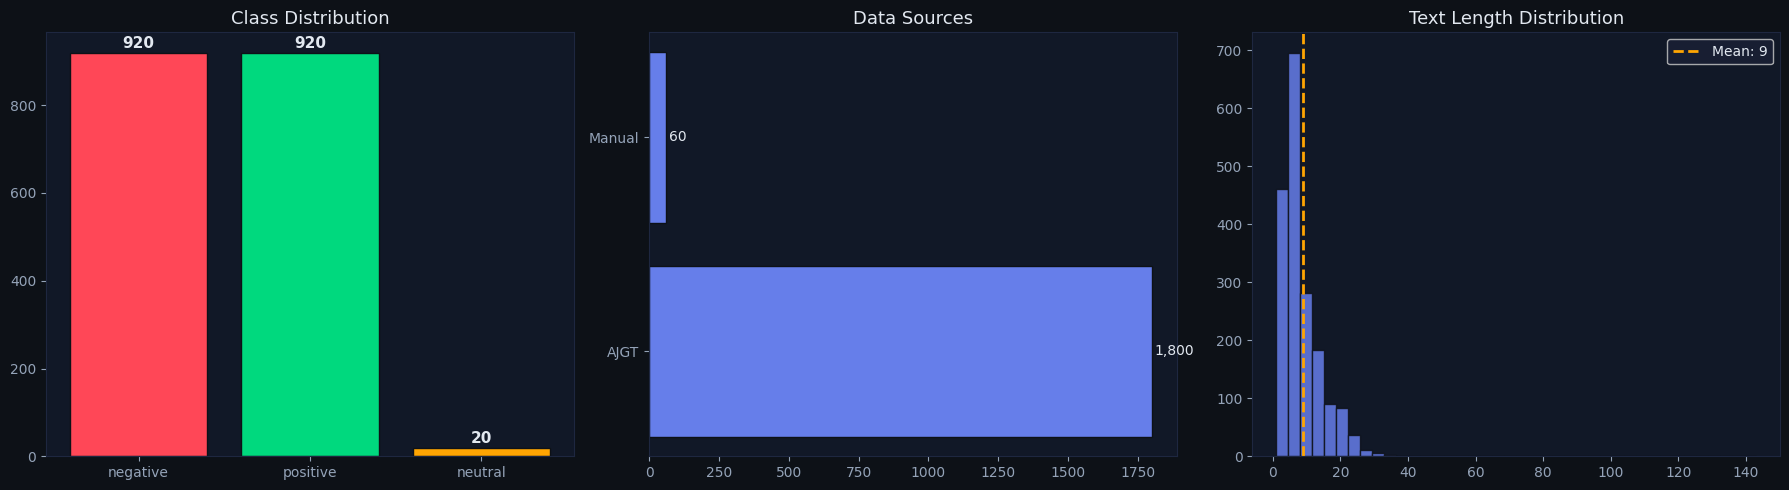

متوسط الطول: 9 | الأقصى: 143


In [11]:
# رسم توزيع الداتا
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#111827')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e2740')

# توزيع الفئات
color_map = {'negative': '#ff4757', 'neutral': '#ffa502', 'positive': '#00d97e'}
cnt = df_balanced['label'].value_counts()
bars = axes[0].bar(cnt.index, cnt.values,
                   color=[color_map.get(l, '#667eea') for l in cnt.index],
                   edgecolor='#0d1117')
for bar, val in zip(bars, cnt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}', ha='center', color='#e2e8f0', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', color='#e2e8f0', fontsize=13)
axes[0].tick_params(colors='#94a3b8')

# مصادر الداتا
if 'source' in df_balanced.columns:
    src = df_balanced['source'].value_counts()
    axes[1].barh(src.index, src.values, color='#667eea', edgecolor='#0d1117')
    axes[1].set_title('Data Sources', color='#e2e8f0', fontsize=13)
    axes[1].tick_params(colors='#94a3b8')
    for i, val in enumerate(src.values):
        axes[1].text(val+10, i, f'{val:,}', va='center', color='#e2e8f0', fontsize=10)

# توزيع الأطوال
lengths = df_balanced['text_clean'].str.split().str.len()
axes[2].hist(lengths, bins=40, color='#667eea', edgecolor='#0d1117', alpha=0.85)
axes[2].axvline(lengths.mean(), color='#ffa502', linestyle='--', linewidth=2,
                label=f'Mean: {lengths.mean():.0f}')
axes[2].set_title('Text Length Distribution', color='#e2e8f0', fontsize=13)
axes[2].tick_params(colors='#94a3b8')
axes[2].legend(facecolor='#1a2035', labelcolor='#e2e8f0')

plt.tight_layout()
plt.savefig('data_analysis.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'متوسط الطول: {lengths.mean():.0f} | الأقصى: {lengths.max()}')

In [12]:
# تقسيم الداتا 70% / 15% / 15%
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.30,
    random_state=42, stratify=df_balanced['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    random_state=42, stratify=temp_df['label']
)

print(f'تدريب     : {len(train_df):,}')
print(f'Validation: {len(val_df):,}')
print(f'اختبار    : {len(test_df):,}')
print(f'الإجمالي  : {len(df_balanced):,}')

تدريب     : 1,302
Validation: 279
اختبار    : 279
الإجمالي  : 1,860


In [13]:
# تحميل mBERT Tokenizer
MODEL_NAME = 'bert-base-multilingual-cased'
MAX_LEN    = 128

print(f'جاري تحميل {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✅ Tokenizer جاهز')

sample = tokenizer('أنا سعيد جداً', max_length=16, truncation=True, padding='max_length')
print('Input IDs sample:', sample['input_ids'])

جاري تحميل bert-base-multilingual-cased...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer جاهز
Input IDs sample: [101, 11341, 10429, 67985, 41535, 16275, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [14]:
# تحويل الداتا لـ HuggingFace Dataset
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        max_length=MAX_LEN,
        truncation=True,
        padding='max_length',
    )

def df_to_dataset(df):
    ds = Dataset.from_dict({
        'text':  df['text_clean'].tolist(),
        'label': df['label_id'].tolist(),
    })
    ds = ds.map(tokenize_function, batched=True)
    ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    return ds

print('جاري تحويل الداتا...')
train_dataset = df_to_dataset(train_df)
val_dataset   = df_to_dataset(val_df)
test_dataset  = df_to_dataset(test_df)

print(f'✅ تدريب: {len(train_dataset):,} | Val: {len(val_dataset):,} | اختبار: {len(test_dataset):,}')

جاري تحويل الداتا...


Map:   0%|          | 0/1302 [00:00<?, ? examples/s]

Map:   0%|          | 0/279 [00:00<?, ? examples/s]

Map:   0%|          | 0/279 [00:00<?, ? examples/s]

✅ تدريب: 1,302 | Val: 279 | اختبار: 279


In [15]:
# مسح أي نموذج قديم من الذاكرة
try:
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()
    print('✅ تم مسح النموذج القديم')
except:
    print('لا يوجد نموذج قديم')

num_labels = len(label2id)
print(f'عدد الفئات: {num_labels}')
print(f'label2id: {label2id}')
print(f'id2label: {id2label}')

لا يوجد نموذج قديم
عدد الفئات: 3
label2id: {'negative': 0, 'neutral': 1, 'positive': 2}
id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [16]:
# تحميل نموذج mBERT بـ 3 فئات
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'✅ النموذج جاهز على: {device}')
print(f'إجمالي Parameters  : {total_params:,}')
print(f'Trainable Parameters: {trainable_params:,}')
print(f'عدد الفئات: {num_labels}')

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ النموذج جاهز على: cuda
إجمالي Parameters  : 177,855,747
Trainable Parameters: 177,855,747
عدد الفئات: 3


In [17]:
# دالة حساب المقاييس
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    acc      = accuracy_score(labels, predictions)
    f1_w     = f1_score(labels, predictions, average='weighted', zero_division=0)
    f1_macro = f1_score(labels, predictions, average='macro',    zero_division=0)
    return {
        'accuracy':    round(acc, 4),
        'f1_weighted': round(f1_w, 4),
        'f1_macro':    round(f1_macro, 4),
    }

print('✅ compute_metrics جاهزة')

✅ compute_metrics جاهزة


In [18]:
# إعداد Training Arguments
training_args = TrainingArguments(
    output_dir                  = './mbert_nlp_model',
    num_train_epochs            = 4,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps                = 200,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    lr_scheduler_type           = 'cosine',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_weighted',
    greater_is_better           = True,
    logging_dir                 = './logs',
    logging_steps               = 50,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
    seed                        = 42,
)
print('✅ Training Arguments جاهزة')

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Training Arguments جاهزة


In [19]:
# إنشاء Trainer وبدء التدريب
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print('🚀 بدء التدريب...')
print(f'Epochs: {training_args.num_train_epochs} | Batch: {training_args.per_device_train_batch_size} | LR: {training_args.learning_rate}')
print('-' * 45)

train_result = trainer.train()

print('\n✅ انتهى التدريب!')
print(f'وقت التدريب: {train_result.metrics["train_runtime"]/60:.1f} دقيقة')

🚀 بدء التدريب...
Epochs: 4 | Batch: 16 | LR: 2e-05
---------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.935625,0.619742,0.702500,0.698600,0.470800
2,0.526724,0.579859,0.713300,0.694700,0.468200
3,0.411004,0.383451,0.849500,0.844900,0.569400
4,0.179752,0.519660,0.842300,0.837600,0.564500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ انتهى التدريب!
وقت التدريب: 1.9 دقيقة


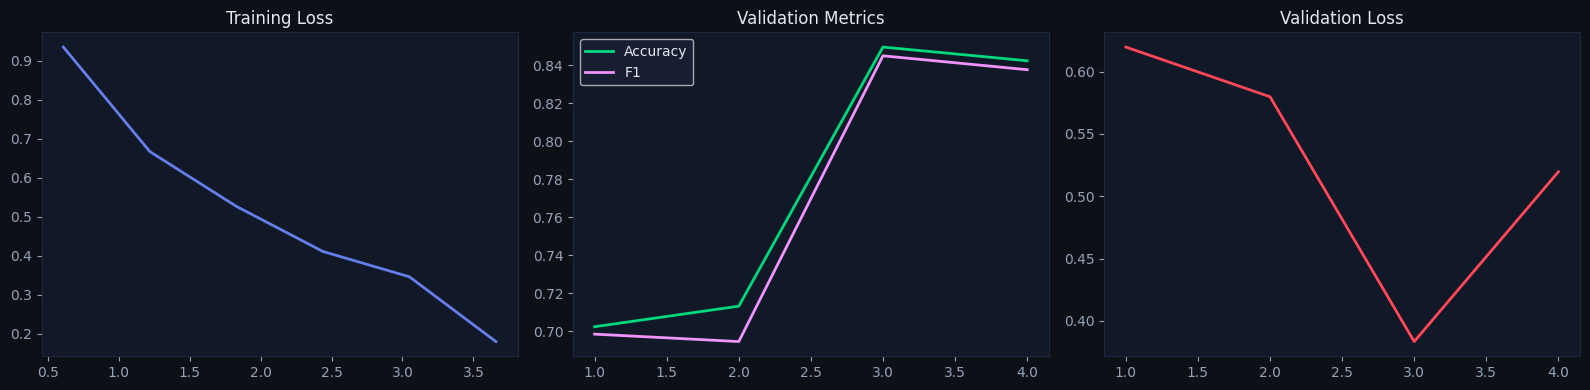

In [20]:
# رسم منحنيات التدريب
history    = trainer.state.log_history
train_loss = [(x['epoch'], x['loss']) for x in history if 'loss' in x and 'eval_loss' not in x]
eval_data  = [(x['epoch'], x.get('eval_loss', 0), x.get('eval_accuracy', 0), x.get('eval_f1_weighted', 0))
              for x in history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#111827')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e2740')

if train_loss:
    ep, loss = zip(*train_loss)
    axes[0].plot(ep, loss, color='#667eea', linewidth=2)
    axes[0].set_title('Training Loss', color='#e2e8f0', fontsize=12)
    axes[0].tick_params(colors='#94a3b8')

if eval_data:
    ep, e_loss, e_acc, e_f1 = zip(*eval_data)
    axes[1].plot(ep, e_acc, color='#00d97e', linewidth=2, label='Accuracy')
    axes[1].plot(ep, e_f1,  color='#f093fb', linewidth=2, label='F1')
    axes[1].set_title('Validation Metrics', color='#e2e8f0', fontsize=12)
    axes[1].legend(facecolor='#1a2035', labelcolor='#e2e8f0')
    axes[1].tick_params(colors='#94a3b8')
    axes[2].plot(ep, e_loss, color='#ff4757', linewidth=2)
    axes[2].set_title('Validation Loss', color='#e2e8f0', fontsize=12)
    axes[2].tick_params(colors='#94a3b8')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [21]:
# تقييم على مجموعة الاختبار
print('🔍 التقييم على مجموعة الاختبار...')

test_results = trainer.predict(test_dataset)
preds        = np.argmax(test_results.predictions, axis=-1)
labels_true  = test_results.label_ids

acc    = accuracy_score(labels_true, preds)
f1_w   = f1_score(labels_true, preds, average='weighted', zero_division=0)
f1_mac = f1_score(labels_true, preds, average='macro',    zero_division=0)

print(f'\n{"="*45}')
print(f'  النتائج ({len(test_df):,} جملة)')
print(f'{"="*45}')
print(f'Accuracy    : {acc*100:.2f}%')
print(f'F1 Weighted : {f1_w*100:.2f}%')
print(f'F1 Macro    : {f1_mac*100:.2f}%')
print(f'\n{classification_report(labels_true, preds, target_names=list(label2id.keys()), zero_division=0)}')

🔍 التقييم على مجموعة الاختبار...



  النتائج (279 جملة)
Accuracy    : 82.80%
F1 Weighted : 82.67%
F1 Macro    : 72.02%

              precision    recall  f1-score   support

    negative       0.83      0.82      0.82       138
     neutral       1.00      0.33      0.50         3
    positive       0.82      0.85      0.84       138

    accuracy                           0.83       279
   macro avg       0.88      0.67      0.72       279
weighted avg       0.83      0.83      0.83       279



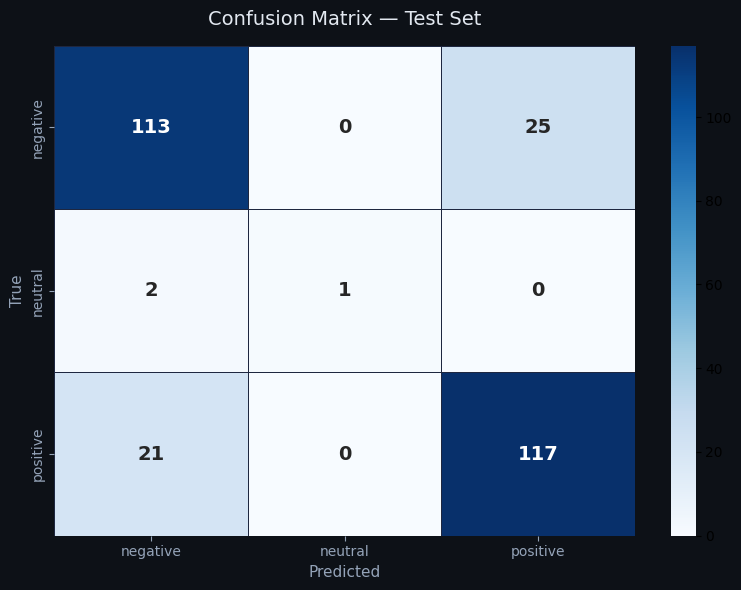

In [22]:
# Confusion Matrix
cm          = confusion_matrix(labels_true, preds)
label_names = [id2label[i] for i in range(num_labels)]

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#111827')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            ax=ax, linewidths=0.5, linecolor='#1e2740',
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title('Confusion Matrix — Test Set', color='#e2e8f0', fontsize=14, pad=15)
ax.set_xlabel('Predicted', color='#94a3b8', fontsize=11)
ax.set_ylabel('True',      color='#94a3b8', fontsize=11)
ax.tick_params(colors='#94a3b8')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [23]:
# حفظ النموذج
SAVE_PATH = './mbert_best_model'

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

model_info = {
    'base_model':    MODEL_NAME,
    'num_labels':    num_labels,
    'label2id':      label2id,
    'id2label':      {str(k): v for k, v in id2label.items()},
    'max_length':    MAX_LEN,
    'test_accuracy': round(float(acc), 4),
    'test_f1':       round(float(f1_w), 4),
    'train_samples': len(train_df),
    'test_samples':  len(test_df),
    'datasets_used': ['AJGT', 'SemEval', 'ASTD', 'ArSAS', 'Amazon_AR', 'Manual'],
}
with open(f'{SAVE_PATH}/model_info.json', 'w', encoding='utf-8') as f:
    json.dump(model_info, f, ensure_ascii=False, indent=2)

print(f'✅ النموذج محفوظ في: {SAVE_PATH}')
print(json.dumps(model_info, ensure_ascii=False, indent=2))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ النموذج محفوظ في: ./mbert_best_model
{
  "base_model": "bert-base-multilingual-cased",
  "num_labels": 3,
  "label2id": {
    "negative": 0,
    "neutral": 1,
    "positive": 2
  },
  "id2label": {
    "0": "negative",
    "1": "neutral",
    "2": "positive"
  },
  "max_length": 128,
  "test_accuracy": 0.828,
  "test_f1": 0.8267,
  "train_samples": 1302,
  "test_samples": 279,
  "datasets_used": [
    "AJGT",
    "SemEval",
    "ASTD",
    "ArSAS",
    "Amazon_AR",
    "Manual"
  ]
}


In [24]:
# دالة التنبؤ
def predict_sentiment(text, return_probs=False):
    model.eval()
    text_clean = re.sub(r'http\S+|@\w+|#\w+|[^\u0600-\u06FFa-zA-Z\s]', ' ', str(text)).strip()

    inputs = tokenizer(
        text_clean,
        max_length=MAX_LEN,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs      = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()
    pred_id    = int(np.argmax(probs))
    pred_label = id2label[pred_id]
    confidence = float(probs[pred_id])
    all_probs  = {id2label[i]: round(float(p)*100, 1) for i, p in enumerate(probs)}

    if return_probs:
        return pred_label, confidence, all_probs
    return pred_label, confidence

# تجربة
tests = [
    'أنا سعيد جداً بهذا المنتج الرائع',
    'هذا سيء جداً ولم يعمل أبداً',
    'الطقس اليوم معتدل',
    'I love this amazing product!',
    'This was the worst decision I have ever made',
    'The meeting is tomorrow at ten',
]
print('\nتجربة التنبؤ:')
for t in tests:
    label, conf, probs = predict_sentiment(t, return_probs=True)
    emoji = '✅' if label=='positive' else '❌' if label=='negative' else '⚖️'
    print(f'{emoji} [{label:8s}] {conf*100:.1f}% | {t[:50]}')


تجربة التنبؤ:
✅ [positive] 96.9% | أنا سعيد جداً بهذا المنتج الرائع
❌ [negative] 58.5% | هذا سيء جداً ولم يعمل أبداً
❌ [negative] 42.1% | الطقس اليوم معتدل
✅ [positive] 93.9% | I love this amazing product!
⚖️ [neutral ] 40.2% | This was the worst decision I have ever made
⚖️ [neutral ] 41.6% | The meeting is tomorrow at ten


In [26]:
# بناء واجهة Gradio
def analyze_with_bert(text):
    if not text.strip():
        return '⚠️ أدخل نصاً', '', ''

    label, conf, probs = predict_sentiment(text, return_probs=True)

    emoji_map  = {'positive': '✅ Positive', 'negative': '❌ Negative', 'neutral': '⚖️ Neutral'}
    circle_map = {'positive': '🟢', 'negative': '🔴', 'neutral': '🟡'}

    result = f"{emoji_map.get(label, label)}  —  Confidence: {conf*100:.1f}%"

    probs_text = '\n'.join([
        f"{circle_map.get(k, '⚪')} {k:10s}: {v}%"
        for k, v in sorted(probs.items(), key=lambda x: -x[1])
    ])

    info = (
        f'Model   : bert-base-multilingual-cased\n'
        f'Data    : AJGT + SemEval + ASTD + ArSAS + Amazon\n'
        f'Test Acc: {acc*100:.1f}%\n'
        f'Test F1 : {f1_w*100:.1f}%'
    )

    return result, probs_text, info

EXAMPLES = [
    ['أنا سعيد جداً بهذا المنتج الرائع'],
    ['هذا سيء جداً ولم يعمل أبداً ومحبط'],
    ['الاجتماع مؤجل إلى الأسبوع القادم'],
    ['I absolutely love this amazing experience!'],
    ['This was the worst decision I have ever made'],
    ['The meeting is scheduled for next Monday'],
]

CSS = """
body { direction: ltr; }
.gradio-container { background: #0d1117 !important; }
label, h1, h2, h3 { color: #e2e8f0 !important; }
.gr-button-primary {
    background: linear-gradient(135deg, #667eea, #764ba2) !important;
    border: none !important;
}
textarea, input { background: #111827 !important; color: #e2e8f0 !important; }
footer { display: none !important; }
"""

with gr.Blocks(css=CSS, title='mBERT Sentiment Analyzer') as demo:

    gr.Markdown("""
    # 🤖 mBERT Sentiment Analyzer
    ### Positive / Negative / Neutral — Arabic & English
    ### Trained on: AJGT + SemEval + ASTD + ArSAS + Amazon AR
    ---
    """)

    with gr.Row():
        with gr.Column(scale=2):
            text_input = gr.Textbox(
                label='Enter text (Arabic or English)',
                placeholder='Type your text here...',
                lines=4,
            )
            with gr.Row():
                analyze_btn = gr.Button('🔍 Analyze', variant='primary', size='lg')
                clear_btn   = gr.Button('🗑️ Clear',   variant='secondary')
            gr.Examples(examples=EXAMPLES, inputs=text_input, label='Examples')

        with gr.Column(scale=1):
            result_out = gr.Textbox(label='📊 Result',              interactive=False, lines=2)
            probs_out  = gr.Textbox(label='📈 Class Probabilities', interactive=False, lines=5)
            info_out   = gr.Textbox(label='ℹ️ Model Info',          interactive=False, lines=4)

    analyze_btn.click(
        fn=analyze_with_bert,
        inputs=[text_input],
        outputs=[result_out, probs_out, info_out],
    )
    clear_btn.click(
        fn=lambda: ('', '', ''),
        outputs=[result_out, probs_out, info_out],
    )

In [27]:
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f2daaefce4a861f0b2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
